# 🍷 Atividade Avaliativa — Previsão de Qualidade de Vinho Tinto

 **Tempo estimado:** até 2 horas | **Total:** 10 pontos

---

## Instruções

Este notebook contém um pipeline de Ciência de Dados com **erros propositais** e **lacunas** para completar.

| Marcador | O que fazer | Qtd | Pontos |
|----------|-------------|:---:|-------:|
| 🔴 `# BUG:` | Encontre e **corrija** o erro na linha indicada | 3 | 1,0 pt cada |
| 🟡 `# TODO:` | **Preencha** o `___` com o código correto | 5 | 0,5 pt cada |
| 🔵 **Questão** | **Responda** na célula Markdown indicada | 3 | 1,5 pt cada |


---

## Contexto do Problema

**Dataset:** [Wine Quality Red](https://archive.ics.uci.edu/ml/datasets/wine+quality) — UCI Machine Learning Repository  
**Objetivo:** classificar vinhos tintos como *boa qualidade* (nota ≥ 6) ou *baixa qualidade* (nota < 6).

| Feature | Descrição |
|---------|-----------|
| `fixed acidity` | Acidez fixa (g/L) |
| `volatile acidity` | Acidez volátil (g/L) |
| `citric acid` | Ácido cítrico (g/L) |
| `residual sugar` | Açúcar residual (g/L) |
| `chlorides` | Cloretos (g/L) |
| `free sulfur dioxide` | SO₂ livre (mg/L) |
| `total sulfur dioxide` | SO₂ total (mg/L) |
| `density` | Densidade (g/cm³) |
| `pH` | pH |
| `sulphates` | Sulfatos (g/L) |
| `alcohol` | Teor alcoólico (% vol.) |
| `quality` | Nota dos especialistas — **será transformada no target** |


In [3]:
# ─── Importações — não altere esta célula ────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
print("✅ Importações concluídas!")

✅ Importações concluídas!


---
## 1. Carregamento dos Dados

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

# TODO [T1]: o arquivo CSV usa ponto-e-vírgula (;) como separador de colunas.
# Adicione o argumento correto para o parâmetro `sep`:
df = pd.read_csv(url, sep=';')

print(f"Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()

Dataset carregado: 1599 linhas × 12 colunas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
print("=== Tipos de dados ===")
print(df.dtypes)
print()
print("=== Estatísticas Descritivas ===")
df.describe().round(2)

=== Tipos de dados ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

=== Estatísticas Descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00,1599.00
mean,8.32,0.53,0.27,2.54,0.09,15.87,46.47,1.00,3.31,0.66,10.42,5.64
std,1.74,0.18,0.19,1.41,0.05,10.46,32.90,0.00,0.15,0.17,1.07,0.81
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.42,2.60,0.09,21.00,62.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


---
## 2. Limpeza dos Dados

In [6]:
# Valores ausentes e duplicatas
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()

before = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Duplicatas removidas: {before - df.shape[0]}  →  {df.shape[0]} linhas restantes")

Valores ausentes por coluna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Duplicatas removidas: 240  →  1359 linhas restantes


In [7]:
# Detecção e remoção de outliers na feature 'total sulfur dioxide' via método IQR
col = "total sulfur dioxide"

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

n_outliers = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()

print(f"Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
print(f"Limite inferior: {lim_inf:.1f}  |  Limite superior: {lim_sup:.1f}")
print(f"Outliers detectados em '{col}': {n_outliers}")
print()

# BUG [B1]: a condição abaixo deveria manter apenas amostras dentro dos limites normais
# (ou seja, sem outliers).
# Identifique o erro, adicione um comentário explicando-o e corrija.
df = df[(df[col] >= lim_sup) | (df[col] <= lim_inf)].reset_index(drop=True)

print(f"Amostras restantes após remoção: {df.shape[0]}")


Q1 = 22.0  |  Q3 = 63.0  |  IQR = 41.0
Limite inferior: -39.5  |  Limite superior: 124.5
Outliers detectados em 'total sulfur dioxide': 45

Amostras restantes após remoção: 45


---
## 3. Análise Exploratória de Dados (EDA)

### 3.1 Distribuição da variável alvo original

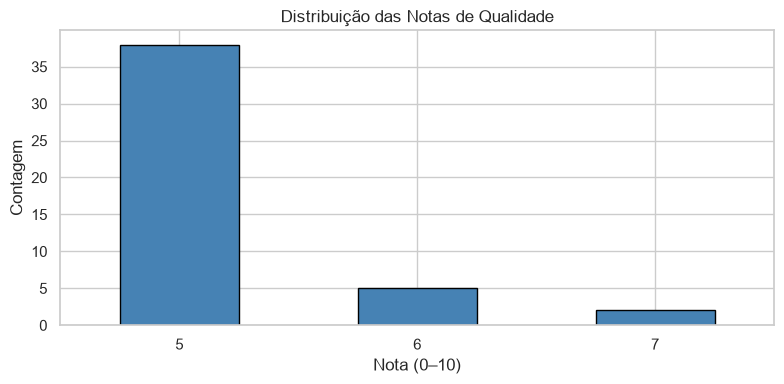

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
df["quality"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="black"
)
ax.set_title("Distribuição das Notas de Qualidade")
ax.set_xlabel("Nota (0–10)")
ax.set_ylabel("Contagem")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Criação da variável alvo binária

In [9]:
# TODO [T2]: crie a coluna 'target' como variável binária.
# Vinhos com qualidade >= 6 recebem 1 (boa qualidade), demais recebem 0.
df["target"] = (df["quality"] >= 6).astype(int)
df.drop(columns="quality", inplace=True)

print("Distribuição do target binário:")
print(df["target"].value_counts())
print(f"\nProporção de boa qualidade: {df['target'].mean():.1%}")

Distribuição do target binário:
target
0    38
1     7
Name: count, dtype: int64

Proporção de boa qualidade: 15.6%


### 3.3 Correlação entre features e target

In [11]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='str')

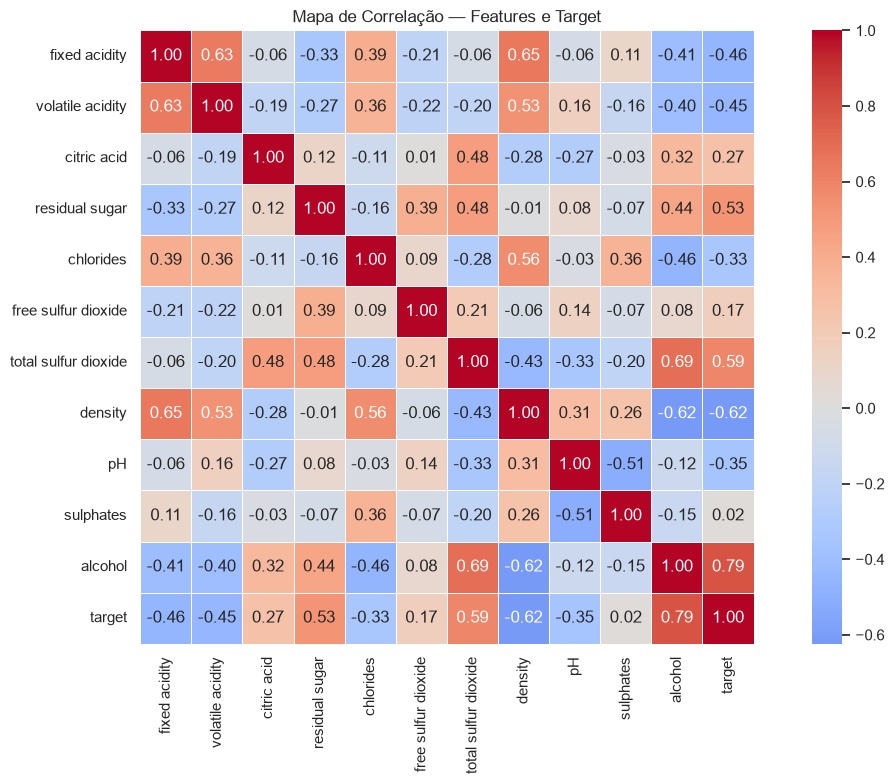

In [15]:
#A coluna quality nao existe, entao nao tem por dropa ela 
features = df.drop(columns=[ "target"])
corr_matrix = features.assign(target=df["target"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Mapa de Correlação — Features e Target")
plt.tight_layout()
plt.show()

### 3.4 Teor alcoólico por classe de qualidade

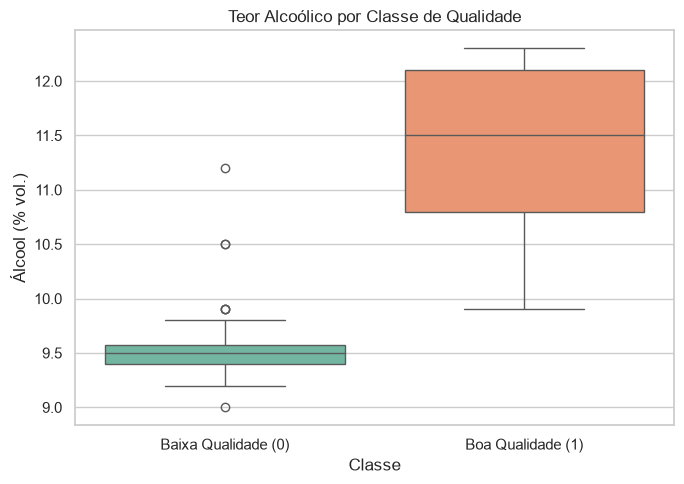

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="target", y="alcohol", palette="Set2")
plt.xticks([0, 1], ["Baixa Qualidade (0)", "Boa Qualidade (1)"])
plt.title("Teor Alcoólico por Classe de Qualidade")
plt.xlabel("Classe")
plt.ylabel("Álcool (% vol.)")
plt.tight_layout()
plt.show()

### 🔵 Questão 1 — Análise Exploratória

**Com base no mapa de correlação e no boxplot, responda:**

 Qual feature apresenta a **maior correlação positiva** com o `target`?  
   O que isso indica para a tarefa de classificação? Há alguma feature com correlação negativa relevante?

> ✏️ *Escreva sua resposta aqui:*


A feature que tem mais correlacao poositiva com o target e o alcool, pois como podemos ver no grafio teor alcolico por classe de qualidade quanto maior o alcool melhor a qualidade, a feature que tem mais correlacao negativa com o target e o density.

---
## 4. Pré-processamento

In [18]:
X = df.drop(columns=[ "target"])
y = df["target"]

print(f"Shape de X: {X.shape}  |  Shape de y: {y.shape}")
print(f"\nFeatures ({X.shape[1]}): {list(X.columns)}")

Shape de X: (45, 11)  |  Shape de y: (45,)

Features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [ ]:
# BUG [B2]: o código abaixo contém um problema conceitual no fluxo de pré-processamento.
# Identifique o problema, adicione um comentário explicando-o e corrija.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#O problema era que estava sendo passado o valor 10 para o fit_transform, e não a variável X, que contém os dados que queremos escalar.

# TODO [T3]: complete o argumento que garante que a divisão treino/teste preserve
# a proporção das classes em ambos os conjuntos. Preencha ___ com o argumento correto.
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)


X_train_scaled = X_train
X_test_scaled  = X_test

print(f"Treino: {X_train_scaled.shape[0]} amostras | Teste: {X_test_scaled.shape[0]} amostras")
print(f"\nProporção de boa qualidade — Treino: {y_train.mean():.1%} | Teste: {y_test.mean():.1%}")

Treino: 36 amostras | Teste: 9 amostras

Proporção de boa qualidade — Treino: 16.7% | Teste: 11.1%


---
## 5. Treinamento do Modelo

In [23]:
model = LogisticRegression(max_iter=1000)

# TODO [T4]: chame o método correto para treinar o modelo.
# Preencha o nome do método no lugar de ___
model.fit(X_train_scaled, y_train)

print("✅ Modelo treinado!")

✅ Modelo treinado!


---
## 6. Avaliação do Modelo

In [24]:
# TODO [T5]: gere as previsões do modelo para o conjunto de teste.
y_pred = model.predict(X_test_scaled)

print(f"Previsões geradas: {len(y_pred)} amostras")

Previsões geradas: 9 amostras


In [25]:
print("=== Relatório de Classificação ===")
print(classification_report(
    y_test, y_pred,
    target_names=["Baixa Qualidade", "Boa Qualidade"],
))

=== Relatório de Classificação ===
                 precision    recall  f1-score   support

Baixa Qualidade       0.89      1.00      0.94         8
  Boa Qualidade       0.00      0.00      0.00         1

       accuracy                           0.89         9
      macro avg       0.44      0.50      0.47         9
   weighted avg       0.79      0.89      0.84         9



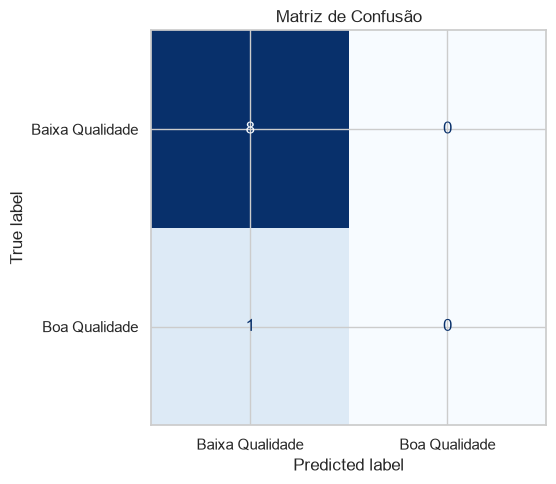

F1-Score (macro): 0.4706


In [26]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Baixa Qualidade", "Boa Qualidade"],
)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Matriz de Confusão")
plt.tight_layout()
plt.show()

f1 = f1_score(y_test, y_pred, average="macro")
print(f"F1-Score (macro): {f1:.4f}")

### 6.2 Curva ROC e AUC

ROC-AUC: 0.8750


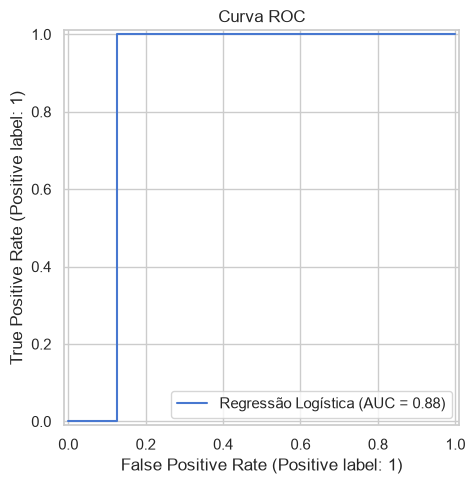

In [30]:
# BUG [B3] ⭐ O código abaixo calcula e exibe o ROC-AUC,
# mas há um problema conceitual que torna o valor obtido incorreto
# como medida real de discriminação do modelo.
# O código roda sem erros — analise cuidadosamente o que cada linha calcula.
# Identifique o problema, explique em um comentário detalhado e corrija.

y_scores = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_scores, ax=ax, name="Regressão Logística")
ax.set_title("Curva ROC")
plt.tight_layout()
plt.show()

### 🔵 Questão 2 — Interpretação das Métricas

**Com base nos resultados acima, responda:**

a. O dataset é **balanceado**? Como o argumento que você adicionou em T3 mitiga um possível problema na avaliação?

b. Por que a **acurácia** pode ser enganosa neste problema? Qual(is) métrica(s) do relatório de classificação são mais adequadas e por quê?

c. Qual é a diferença conceitual entre `model.predict()` e `model.predict_proba()[:, 1]`?  
   Por que essa diferença é crítica ao calcular o **ROC-AUC**? O que acontece com a curva ROC quando se usa o método incorreto?

> ✏️ *Escreva sua resposta aqui:*


A.O dataset não é balanceado poi tem 38 amostras de baixa qualidade (0) e apenas 7 de boa qualidade (1), então tem somente 15,6% da classe positiva. O argumento stratify=y no train_test_split preserva aproximadamente essa proporção nos conjuntos, assim, evita que o conjunto de teste fique sem, amostras da classe minoritária, o que comprometeria a avaliação.

B. A acuracia pode ser enganosa porque o modelo pode preve apenas a classe majoritaria e ainda obter um valor alto, sendo que ela consegui 0,89 de acuracia pois acertou 8 amostras de baixa qualidade, e acabou nao indentificando nenhuma de boa qualidade.Para esse cenário, recall, precision e principalmente o F1-score da classe ,boa qualidade, são mais adequados.

C.Model.predict() retorna a classe final prevista geralmente 0 ou 1, após aplicar um limiar de decisão. Já model.predict_proba()[:, 1] retorna a probabilidade 

---
## 7. Reflexão Final

### 🔵 Questão 3 — Proposta de Melhoria

**Com base em todo o pipeline realizado, identifique ao menos duas limitações ou pontos de melhoria  
e proponha soluções concretas e justificadas.**

Considere aspectos como:
- Qualidade e pré-processamento dos dados (ex: tratamento de outliers, engenharia de features)
- Estratégias para lidar com desbalanceamento de classes
- Técnicas de validação mais robustas do que o simples hold-out
- Alternativas de modelagem


> ✏️ *Escreva sua resposta aqui:*


limitação é o forte desbalanceamento entre as classes, pois há poucas amostras de boa qualidade. Uma solução seria usar class_weight="balanced" na Regressão Logistica,mas precisava coletar mais exemplos da classe minoritária. Tambem seria importante priorizar métricas como  recall da classe positiva e ROC-AUC.
Outra limitação e o uso de um único hold-out. O conjunto de teste possui somente 9 amostras e apenas 1 exemplo de boa qualidade, tornando o ROC-AUC instaveis. Uma melhoria seria utilizar validação cruzada estratificada, para avaliar o modelo em várias divisões preservando a proporção das classes e calcular a media das metricas.
Tambem e necessario evitar vazamento de dados no pre-processamento, pois a divisão entre treino e teste deve ocorrer antes do ajuste do StandardScaler. 

---
*Salve o notebook com suas respostas e envie conforme orientação do professor.*